In [53]:
from google.colab import files
uploaded = files.upload()


Saving final_data_with_reason.csv to final_data_with_reason (4).csv


In [54]:
import pandas as pd

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

df.head()


,date,machine_id,assembly_line_no,hydraulic_pressurebar,coolant_pressurebar,air_system_pressurebar,coolant_temperature,hydraulic_oil_temperaturec,spindle_bearing_temperaturec,spindle_vibrationm,...,voltagevolts_is_outlier,torquenm_is_outlier,cuttingkn_is_outlier,downtime_flag,temp_diff,vibration_total,pressure_ratio,normalized_speed,load_index,final_reason
0,31-12-2021,Makino-L1-Unit1-2013,Shopfloor-L1,71.04,6.933725,6.284965,25.6,46.0,33.4,1.291,...,0,0,0,1,-20.4,27.783,10.245575,0.926137,17.912728,High_CuttingForce_with_Low_HydraulicPressure
1,31-12-2021,Makino-L1-Unit1-2013,Shopfloor-L1,125.33,4.936892,6.196733,35.3,47.4,34.6,1.382,...,0,0,0,1,-12.1,26.656,25.386418,0.710234,10.746023,Low_Torque
2,31-12-2021,Makino-L3-Unit1-2015,Shopfloor-L3,71.12,6.839413,6.655448,13.1,40.7,33.0,1.319,...,0,0,0,1,-27.6,31.927,10.398553,0.710055,17.899487,High_CuttingForce_with_Low_HydraulicPressure
3,31-05-2022,Makino-L2-Unit1-2015,Shopfloor-L2,139.34,4.574382,6.560394,24.4,44.2,40.6,0.618,...,0,0,0,1,-19.8,31.409,30.460945,0.660336,19.167020,High_CuttingForce
4,31-03-2022,Makino-L1-Unit1-2013,Shopfloor-L1,60.51,6.893182,6.141238,4.1,47.3,31.4,0.983,...,0,0,0,1,-43.2,26.499,8.778239,0.948814,18.926112,High_CuttingForce_with_Low_HydraulicPressure


In [55]:
df['date'] = pd.to_datetime(df['date'], format="%d-%m-%Y")


Machine Filter

In [56]:
machine_id = "Makino-L1-Unit1-2013"

machine_df = df[df['machine_id'] == machine_id].copy()
machine_df = machine_df.sort_values('date')
machine_df.head()


,date,machine_id,assembly_line_no,hydraulic_pressurebar,coolant_pressurebar,air_system_pressurebar,coolant_temperature,hydraulic_oil_temperaturec,spindle_bearing_temperaturec,spindle_vibrationm,...,voltagevolts_is_outlier,torquenm_is_outlier,cuttingkn_is_outlier,downtime_flag,temp_diff,vibration_total,pressure_ratio,normalized_speed,load_index,final_reason
1053,2021-12-17,Makino-L1-Unit1-2013,Shopfloor-L1,74.540000,6.580195,6.528837,24.4,48.1,36.6,0.778,...,0,0,0,1,-23.7,25.826,11.327931,1.000000,17.823750,High_CuttingForce_with_Low_HydraulicPressure
1054,2021-12-17,Makino-L1-Unit1-2013,Shopfloor-L1,88.280000,6.839413,6.560381,5.2,49.4,34.2,1.266,...,0,0,0,1,-44.2,31.472,12.907540,1.000000,11.940501,Low_Torque_with_Low_HydraulicPressure
464,2021-12-24,Makino-L1-Unit1-2013,Shopfloor-L1,114.145368,5.145508,6.637016,21.7,45.5,30.3,0.666,...,0,0,0,0,-23.8,31.627,22.183496,0.740244,17.014929,Normal_Operation
321,2021-12-26,Makino-L1-Unit1-2013,Shopfloor-L1,115.776093,3.164805,6.156036,11.9,49.5,40.5,1.147,...,0,0,0,0,-37.6,33.313,36.582382,0.740602,16.791130,Normal_Operation
240,2021-12-27,Makino-L1-Unit1-2013,Shopfloor-L1,76.690000,6.839413,6.046277,23.7,51.7,29.4,0.671,...,0,0,0,1,-28.0,28.944,11.212950,0.838144,17.787448,High_CuttingForce_with_Low_HydraulicPressure


Daily Aggregation

In [57]:
daily_df = machine_df.groupby('date').agg({
    'downtime_flag': 'max',
    'vibration_total': 'mean',
    'pressure_ratio': 'mean',
    'load_index': 'mean',
    'temp_diff': 'mean',
    'torquenm': 'mean',
    'hydraulic_pressurebar': 'mean'
})

daily_df = daily_df.sort_index()
daily_df.head()


,downtime_flag,vibration_total,pressure_ratio,load_index,temp_diff,torquenm,hydraulic_pressurebar
date,,,,,,,
2021-12-17,1,28.649,12.117736,14.882126,-33.95,19.912322,81.410000
2021-12-24,0,31.627,22.183496,17.014929,-23.80,23.068471,114.145368
2021-12-26,0,33.313,36.582382,16.791130,-37.60,23.057329,115.776093
2021-12-27,1,30.847,14.209887,17.646553,-27.35,23.895790,80.165000
2021-12-28,1,30.196,16.890626,17.256128,-18.35,23.650897,85.305332


Q1 – Does the daily vibration show an increasing or decreasing trend over time?

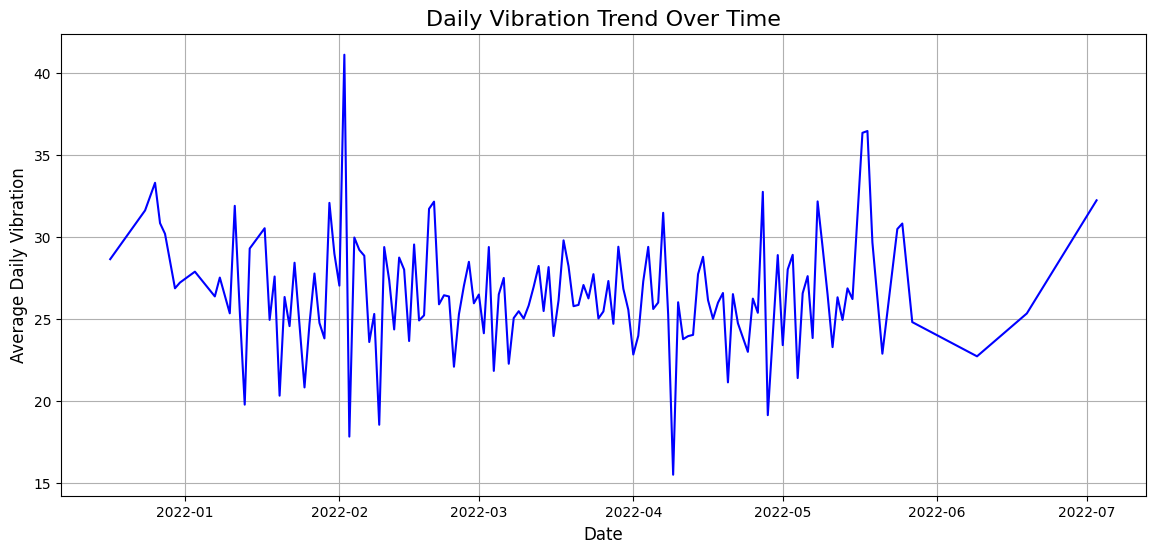

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(daily_df.index, daily_df['vibration_total'], color='blue')
plt.title("Daily Vibration Trend Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Daily Vibration", fontsize=12)
plt.grid(True)
plt.show()


Q2 - Is there any seasonality pattern in the Load Index across months?

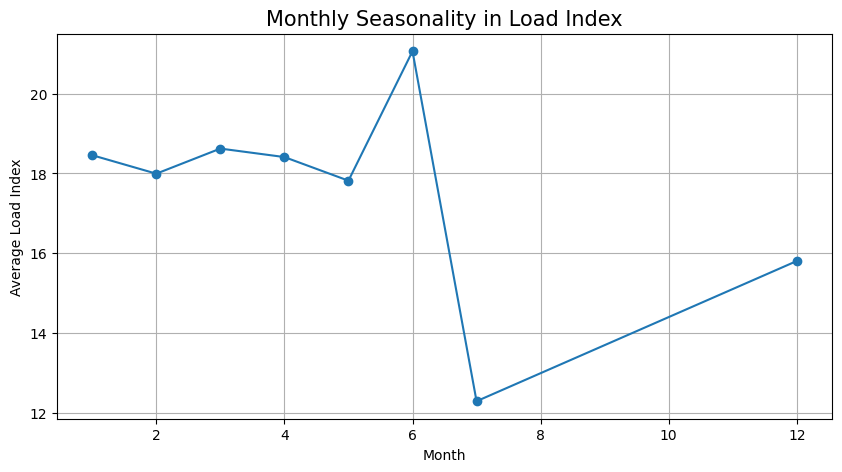

In [59]:
import matplotlib.pyplot as plt

daily_df['month'] = daily_df.index.month


monthly_load = daily_df.groupby('month')['load_index'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_load.index, monthly_load.values, marker='o')
plt.title("Monthly Seasonality in Load Index", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Average Load Index")
plt.grid(True)
plt.show()


Q3 — Is there a relationship between Pressure Ratio and Downtime?

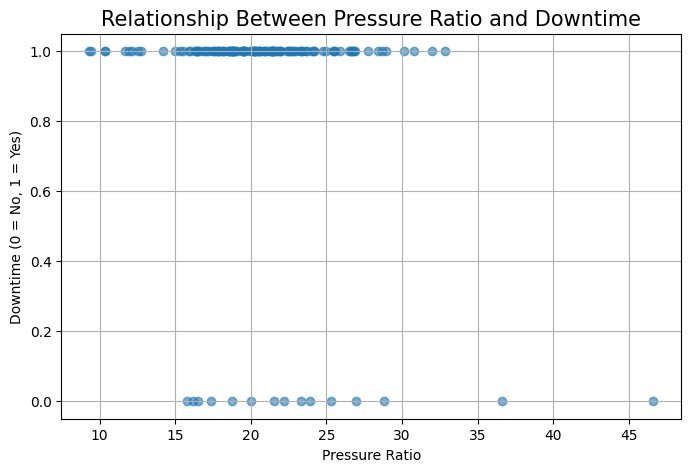

np.float64(-0.216872368939974)

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(daily_df['pressure_ratio'], daily_df['downtime_flag'], alpha=0.6)
plt.title("Relationship Between Pressure Ratio and Downtime", fontsize=15)
plt.xlabel("Pressure Ratio")
plt.ylabel("Downtime (0 = No, 1 = Yes)")
plt.grid(True)
plt.show()

corr = daily_df['pressure_ratio'].corr(daily_df['downtime_flag'])
corr

Machine Learning model

In [61]:
daily_df['vibration_yesterday'] = daily_df['vibration_total'].shift(1)
daily_df['pressure_yesterday'] = daily_df['pressure_ratio'].shift(1)
daily_df['load_yesterday'] = daily_df['load_index'].shift(1)
daily_df['hyd_pressure_yesterday'] = daily_df['hydraulic_pressurebar'].shift(1)
daily_df['torque_yesterday'] = daily_df['torquenm'].shift(1)

daily_df = daily_df.dropna()


In [62]:
features = [
    'vibration_total',
    'pressure_ratio',
    'load_index',
    'hydraulic_pressurebar',
    'torquenm',
    'vibration_yesterday',
    'pressure_yesterday',
    'load_yesterday',
    'hyd_pressure_yesterday',
    'torque_yesterday'
]


In [63]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

X = daily_df[features]
y = daily_df['downtime_flag']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tscv = TimeSeriesSplit(n_splits=5)

accuracies = []
last_report = None

for train_index, test_index in tscv.split(X_scaled):

    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    last_report = classification_report(y_test, y_pred)


print("Average Accuracy:", sum(accuracies) / len(accuracies))
print("Last Fold Report:\n", last_report)


Average Accuracy: 0.9217391304347826
Last Fold Report:
               precision    recall  f1-score   support

           0       0.67      0.44      0.53         9
           1       0.71      0.86      0.77        14

    accuracy                           0.70        23
   macro avg       0.69      0.65      0.65        23
weighted avg       0.69      0.70      0.68        23



In [64]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

def train_machine(df, machine_id):
    print(f" Training model for: {machine_id}")

    machine_df = df[df['machine_id'] == machine_id].copy()
    machine_df = machine_df.sort_values('date')

    daily_df = machine_df.groupby('date').agg({
        'downtime_flag': 'max',
        'vibration_total': 'mean',
        'pressure_ratio': 'mean',
        'load_index': 'mean',
        'temp_diff': 'mean',
        'torquenm': 'mean',
        'hydraulic_pressurebar': 'mean'
    })
    daily_df = daily_df.sort_index()

    daily_df['vibration_yesterday'] = daily_df['vibration_total'].shift(1)
    daily_df['pressure_yesterday'] = daily_df['pressure_ratio'].shift(1)
    daily_df['load_yesterday'] = daily_df['load_index'].shift(1)
    daily_df['hyd_pressure_yesterday'] = daily_df['hydraulic_pressurebar'].shift(1)
    daily_df['torque_yesterday'] = daily_df['torquenm'].shift(1)


    daily_df = daily_df.dropna()

    features = [
        'vibration_total',
        'pressure_ratio',
        'load_index',
        'hydraulic_pressurebar',
        'torquenm',
        'vibration_yesterday',
        'pressure_yesterday',
        'load_yesterday',
        'hyd_pressure_yesterday',
        'torque_yesterday'
    ]

    X = daily_df[features]
    y = daily_df['downtime_flag']


    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    tscv = TimeSeriesSplit(n_splits=5)
    accuracies = []
    last_report = None

    for train_index, test_index in tscv.split(X_scaled):
        X_train, X_test = X_scaled[train_index], X_scaled[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            random_state=42
        )
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracies.append(accuracy_score(y_test, y_pred))
        last_report = classification_report(y_test, y_pred)

    avg_acc = sum(accuracies) / len(accuracies)

    print("Average Accuracy:", avg_acc)
    print("\nLast Fold Report:\n", last_report)


In [65]:
train_machine(df, "Makino-L2-Unit1-2015")
train_machine(df, "Makino-L3-Unit1-2015")


 Training model for: Makino-L2-Unit1-2015
Average Accuracy: 0.8869565217391304

Last Fold Report:
               precision    recall  f1-score   support

           0       1.00      0.40      0.57        10
           1       0.68      1.00      0.81        13

    accuracy                           0.74        23
   macro avg       0.84      0.70      0.69        23
weighted avg       0.82      0.74      0.71        23

 Training model for: Makino-L3-Unit1-2015
Average Accuracy: 0.9454545454545455

Last Fold Report:
               precision    recall  f1-score   support

           0       1.00      0.70      0.82        10
           1       0.80      1.00      0.89        12

    accuracy                           0.86        22
   macro avg       0.90      0.85      0.86        22
weighted avg       0.89      0.86      0.86        22



Forcasting

In [66]:
def forecast_tomorrow(df, machine_id, model, scaler):
    print(f"\n Forecast For {machine_id} \n")

    machine_df = df[df['machine_id'] == machine_id].copy()
    machine_df = machine_df.sort_values('date')

    daily_df = machine_df.groupby('date').agg({
        'downtime_flag': 'max',
        'vibration_total': 'mean',
        'pressure_ratio': 'mean',
        'load_index': 'mean',
        'temp_diff': 'mean',
        'torquenm': 'mean',
        'hydraulic_pressurebar': 'mean'
    })
    daily_df = daily_df.sort_index()

    daily_df['vibration_yesterday'] = daily_df['vibration_total'].shift(1)
    daily_df['pressure_yesterday'] = daily_df['pressure_ratio'].shift(1)
    daily_df['load_yesterday'] = daily_df['load_index'].shift(1)
    daily_df['hyd_pressure_yesterday'] = daily_df['hydraulic_pressurebar'].shift(1)
    daily_df['torque_yesterday'] = daily_df['torquenm'].shift(1)

    daily_df = daily_df.dropna()

    features = [
        'vibration_total',
        'pressure_ratio',
        'load_index',
        'hydraulic_pressurebar',
        'torquenm',
        'vibration_yesterday',
        'pressure_yesterday',
        'load_yesterday',
        'hyd_pressure_yesterday',
        'torque_yesterday'
    ]

    latest = daily_df.iloc[-1][features].values.reshape(1, -1)

    latest_scaled = scaler.transform(latest)

    pred = model.predict(latest_scaled)[0]
    prob = model.predict_proba(latest_scaled)[0][1]

    print(f"Prediction for tomorrow: {int(pred)}")
    print(f"Probability of downtime: {prob:.3f}")

    return pred, prob


In [67]:
def train_and_get_model(df, machine_id):

    machine_df = df[df['machine_id'] == machine_id].copy()
    machine_df = machine_df.sort_values('date')

    daily_df = machine_df.groupby('date').agg({
        'downtime_flag': 'max',
        'vibration_total': 'mean',
        'pressure_ratio': 'mean',
        'load_index': 'mean',
        'temp_diff': 'mean',
        'torquenm': 'mean',
        'hydraulic_pressurebar': 'mean'
    })
    daily_df = daily_df.sort_index()

    daily_df['vibration_yesterday'] = daily_df['vibration_total'].shift(1)
    daily_df['pressure_yesterday'] = daily_df['pressure_ratio'].shift(1)
    daily_df['load_yesterday'] = daily_df['load_index'].shift(1)
    daily_df['hyd_pressure_yesterday'] = daily_df['hydraulic_pressurebar'].shift(1)
    daily_df['torque_yesterday'] = daily_df['torquenm'].shift(1)

    daily_df = daily_df.dropna()

    features = [
        'vibration_total',
        'pressure_ratio',
        'load_index',
        'hydraulic_pressurebar',
        'torquenm',
        'vibration_yesterday',
        'pressure_yesterday',
        'load_yesterday',
        'hyd_pressure_yesterday',
        'torque_yesterday'
    ]

    X = daily_df[features]
    y = daily_df['downtime_flag']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        random_state=42
    )
    model.fit(X_scaled, y)

    return model, scaler


In [68]:
model_L1, scaler_L1 = train_and_get_model(df, "Makino-L1-Unit1-2013")
model_L2, scaler_L2 = train_and_get_model(df, "Makino-L2-Unit1-2015")
model_L3, scaler_L3 = train_and_get_model(df, "Makino-L3-Unit1-2015")


In [69]:
forecast_tomorrow(df, "Makino-L1-Unit1-2013", model_L1, scaler_L1)
forecast_tomorrow(df, "Makino-L2-Unit1-2015", model_L2, scaler_L2)
forecast_tomorrow(df, "Makino-L3-Unit1-2015", model_L3, scaler_L3)



 Forecast For Makino-L1-Unit1-2013 

Prediction for tomorrow: 1
Probability of downtime: 0.790

 Forecast For Makino-L2-Unit1-2015 



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Prediction for tomorrow: 0
Probability of downtime: 0.108

 Forecast For Makino-L3-Unit1-2015 

Prediction for tomorrow: 0
Probability of downtime: 0.255


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


(np.int64(0), np.float64(0.2552324929971989))